# **Predicción del Precio de viviendas**

### Carga de funciones

In [1]:
import pandas as pd # Dataframes
import numpy as np # Arreglos y matrices
import scipy.stats as stats
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt # Graficos
import seaborn as sns  # para análisis gráficos
import random # para generar aleatorios
from sklearn.ensemble import IsolationForest # para retiro de outlier de forma multivariada
from sklearn.linear_model import ElasticNet

Información del atributo (en orden):

Los datos del precio de la vivienda se han utilizado en muchos documentos de aprendizaje automático que abordan la regresión

- **CRIM**: tasa de criminalidad per cápita por ciudad
- **ZN**: proporción de tierra residencial dividida en zonas para lotes de más de 25,000 pies cuadrados.
- **INDUS**: proporción de acres de negocios no minoristas por ciudad
- **CHAS**: variable ficticia Charles River (= 1 si el tramo limita con el río; 0 en caso contrario)
- **NOX**: concentración de óxidos nítricos (partes por 10 millones)
- **RM**: número medio de habitaciones por vivienda
- **TAX**:tasa de impuesto a la propiedad de valor total
- **EDAD**: proporción de unidades ocupadas por el propietario construidas antes de 1940
- **DIS**: distancias ponderadas a cinco centros de empleo
- **RAD**: índice de accesibilidad a autopistas radiales
- **IMPUESTO**: tasa impositiva sobre el valor total de la propiedad por 10,000
- **PTRATIO**: relación alumno-maestro por localidad
- **B**: 1000 (Bk - 0.63) ^ 2 donde Bk es la proporción de migrantes por ciudad
- **LSTAT**:% menor estado de la población
- **MEDV**: valor medio de viviendas ocupadas por el propietario en $ 1000

### Carga de datos

In [2]:
vivienda = pd.read_csv("../data/raw/vivienda.csv")
vivienda.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [3]:
# Eliminar una columna
vivienda = vivienda.drop('Unnamed: 0', axis=1)
vivienda.head(3)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7


# **1. Análisis Descriptivo**

In [4]:
# Trasformamos al tipo de variable correcto
vivienda['CHAS'] = vivienda['CHAS'].astype('object')

In [5]:
var_numerics = vivienda.select_dtypes(include=['number']).columns.tolist()
var_numerics

['CRIM',
 'ZN',
 'INDUS',
 'NOX',
 'RM',
 'AGE',
 'DIS',
 'RAD',
 'TAX',
 'PTRATIO',
 'B',
 'LSTAT',
 'PRICE']

In [6]:
vivienda.describe() # describe es una funcion para tener un reporte estadistico basico rapidamente

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.00000,459.000000,459.000000,459.000000
mean,3.568016,12.527233,10.532549,0.549938,6.305691,67.772767,3.909653,8.851852,390.427015,18.28671,355.029651,12.445773,22.880610
std,8.930732,24.189816,6.738346,0.119705,0.720359,28.883597,2.171832,8.278441,159.966224,2.19928,93.797691,7.296410,9.491573
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.60000,0.320000,1.730000,5.000000
25%,0.076890,0.000000,4.930000,0.447000,5.888000,42.150000,2.058100,4.000000,277.000000,16.80000,375.425000,6.700000,17.050000
50%,0.228760,0.000000,8.140000,0.520000,6.223000,76.900000,3.421700,5.000000,311.000000,18.60000,391.130000,10.560000,21.600000
75%,2.322445,20.000000,18.100000,0.631000,6.635000,94.300000,5.400700,8.000000,437.000000,20.20000,396.025000,16.820000,26.600000
max,88.976200,100.000000,25.650000,0.871000,8.780000,100.000000,12.126500,24.000000,666.000000,22.00000,396.900000,37.970000,50.000000


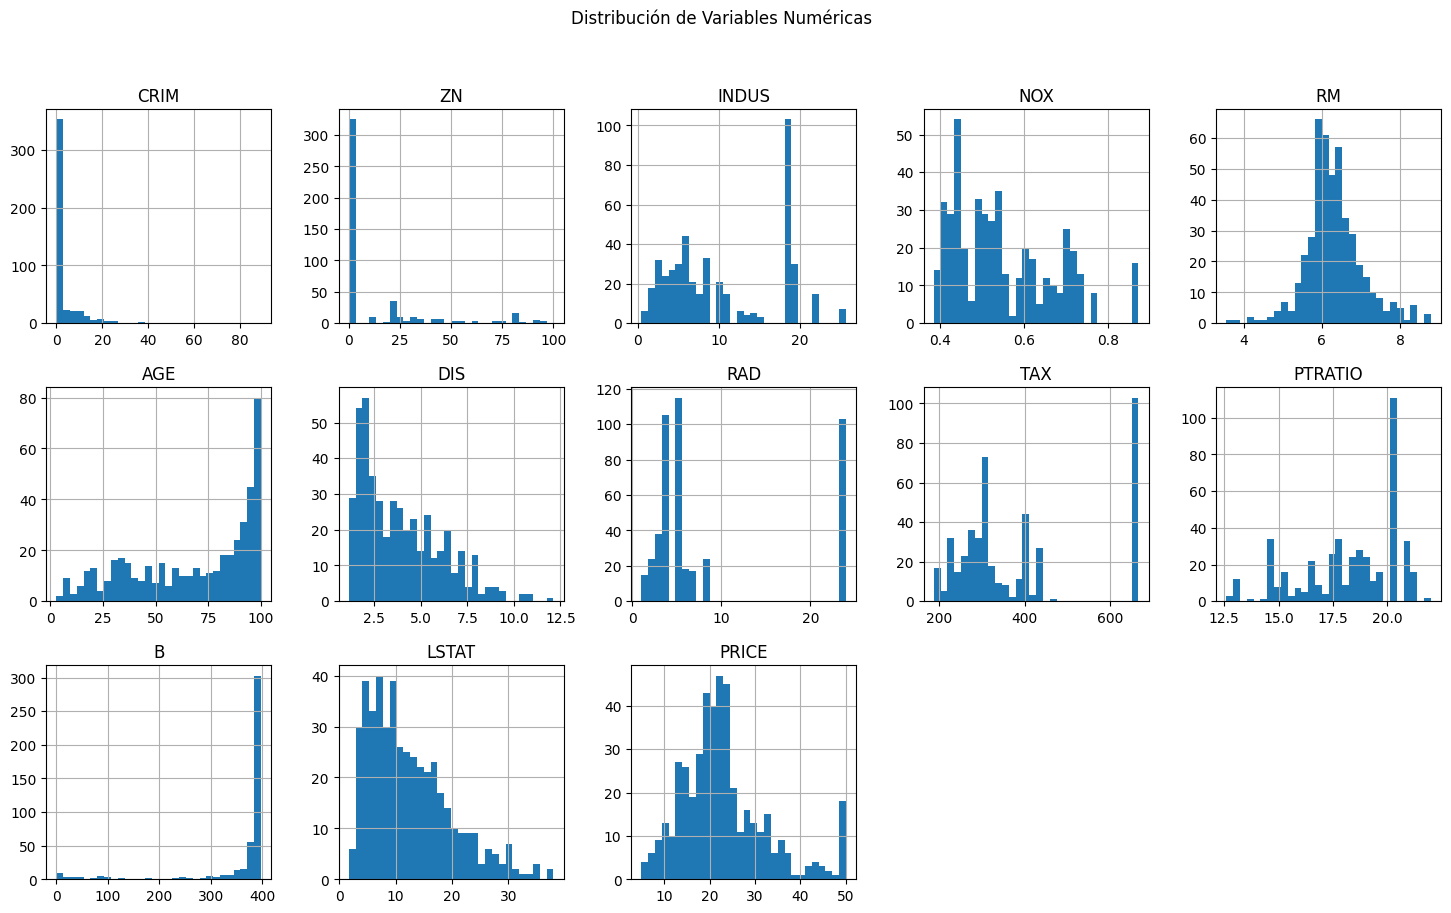

In [7]:
vivienda[var_numerics].hist(figsize=(18, 10), layout=(3,5), bins=30)
plt.suptitle('Distribución de Variables Numéricas')
plt.show()

In [8]:
import sys
sys.path.append("../src")

from preprocessing import imputar_valores_extremos, analizar_distribucion, obtener_correlaciones

In [9]:
# Antes de poder realizar el modelo de regresión lineal debemos ver si existe asociación y de qué tipo es.
# coeficiente de correlación
vivienda[var_numerics].corr()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
CRIM,1.000000,-0.202616,0.427685,0.427651,-0.226822,0.359031,-0.389402,0.652669,0.622398,0.297041,-0.396768,0.466295,-0.397261
ZN,-0.202616,1.000000,-0.531240,-0.511010,0.308333,-0.575651,0.657429,-0.305073,-0.294540,-0.370046,0.190713,-0.414955,0.352278
INDUS,0.427685,-0.531240,1.000000,0.785093,-0.393571,0.658919,-0.716299,0.598652,0.686797,0.344381,-0.398493,0.614933,-0.476402
NOX,0.427651,-0.511010,0.785093,1.000000,-0.302923,0.742449,-0.770900,0.639784,0.692935,0.165496,-0.395218,0.599103,-0.422701
RM,-0.226822,0.308333,-0.393571,-0.302923,1.000000,-0.246665,0.193969,-0.227709,-0.291109,-0.358313,0.135343,-0.608563,0.696222
AGE,0.359031,-0.575651,0.658919,0.742449,-0.246665,1.000000,-0.753934,0.491326,0.526643,0.248994,-0.283294,0.609203,-0.365332
DIS,-0.389402,0.657429,-0.716299,-0.770900,0.193969,-0.753934,1.000000,-0.524053,-0.542715,-0.200938,0.312367,-0.496431,0.232413
RAD,0.652669,-0.305073,0.598652,0.639784,-0.227709,0.491326,-0.524053,1.000000,0.928195,0.457461,-0.501840,0.523739,-0.404968
TAX,0.622398,-0.294540,0.686797,0.692935,-0.291109,0.526643,-0.542715,0.928195,1.000000,0.433385,-0.506508,0.558139,-0.474569
PTRATIO,0.297041,-0.370046,0.344381,0.165496,-0.358313,0.248994,-0.200938,0.457461,0.433385,1.000000,-0.200892,0.378450,-0.503440


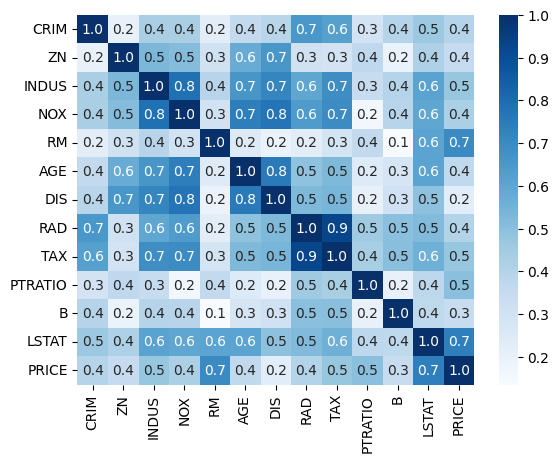

In [10]:
# Gráfico de calor de correlaciones
sns.heatmap(abs(vivienda[var_numerics].corr()), annot=True, fmt='.1f', cmap='Blues')
plt.show()

In [13]:
# Retirando correlaciones altas
# -----
result_df_corr = obtener_correlaciones(vivienda, var_numerics)
result_df_corr.head(15)

,Var1,Var2,Correlation
0,RAD,TAX,0.928195
1,NOX,INDUS,0.785093
2,NOX,AGE,0.742449
3,RM,PRICE,0.696222
4,TAX,NOX,0.692935
5,TAX,INDUS,0.686797
6,INDUS,AGE,0.658919
7,ZN,DIS,0.657429
8,RAD,CRIM,0.652669
9,RAD,NOX,0.639784


In [15]:
result_df_corr.to_csv('../results/correlations.csv', index=False)

In [16]:
# Filtrar correlaciones altas con PRECIO
var_df_corr = result_df_corr[~(((result_df_corr['Var1'] == 'PRICE') | (result_df_corr['Var2'] == 'PRICE')) & (result_df_corr['Correlation'].abs() >= 0.6))]
var_df_corr.head(15)

,Var1,Var2,Correlation
0,RAD,TAX,0.928195
1,NOX,INDUS,0.785093
2,NOX,AGE,0.742449
4,TAX,NOX,0.692935
5,TAX,INDUS,0.686797
6,INDUS,AGE,0.658919
7,ZN,DIS,0.657429
8,RAD,CRIM,0.652669
9,RAD,NOX,0.639784
10,TAX,CRIM,0.622398


In [17]:
# Filtrar las filas donde "PRICE" aparece en "Variable 1" o "Variable 2"
price_df_corr = result_df_corr[(result_df_corr['Var1'] == 'PRICE') | (result_df_corr['Var2'] == 'PRICE')]
price_df_corr

,Var1,Var2,Correlation
3,RM,PRICE,0.696222
26,PRICE,ZN,0.352278
27,B,PRICE,0.347007
33,PRICE,DIS,0.232413
50,AGE,PRICE,-0.365332
57,CRIM,PRICE,-0.397261
59,RAD,PRICE,-0.404968
61,NOX,PRICE,-0.422701
62,PRICE,TAX,-0.474569
63,PRICE,INDUS,-0.476402


In [18]:
# creamos un nuevo dataframe
# -------

df = vivienda.copy()

# -------

In [19]:
df = df.drop(['RAD', 'NOX'], axis=1)

In [20]:
vivienda.shape, df.shape

((459, 14), (459, 12))

In [21]:
var_numerics.remove('RAD')
var_numerics.remove('NOX')
var_numerics

['CRIM',
 'ZN',
 'INDUS',
 'RM',
 'AGE',
 'DIS',
 'TAX',
 'PTRATIO',
 'B',
 'LSTAT',
 'PRICE']

Revisando presencia de valores atípicos